# Contractor Operations Analytics - Python Analysis

This notebook extends the SQL EDA with distribution analysis,
visualization, and statistical testing.

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt

from sqlalchemy import create_engine

from pathlib import Path
import os 
from dotenv import load_dotenv

In [3]:
project_root = Path.cwd().parent 

load_dotenv(project_root / ".env")

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)


In [4]:
query = """
select *
from vw_ticket_analysis
"""

df = pd.read_sql(query, engine)

In [5]:
df.shape

(10000, 39)

In [6]:
df.head()

,ticket_id,ticket_number,title,category,source,created_at,first_response_at,resolved_at,closed_at,priority_name,...,assignment_count,rejection_count,first_assigned_at,first_accepted_at,is_reassigned,response_time_minutes,resolution_time_minutes,assignment_delay_minutes,response_sla_breached,resolution_sla_breached
0,1,INC-000001,Connectivity issue detected,Connectivity,Service Desk,2024-08-01 02:37:47,2024-08-01 09:12:47,2024-08-01 19:41:47,2024-08-01 20:08:47,Low,...,1,0,2024-08-01 03:19:47,2024-08-01 03:34:47,False,395.0,1024.0,42.0,True,False
1,2,INC-000002,Configuration issue detected,Configuration,Monitoring,2024-08-01 03:18:47,2024-08-01 03:59:47,2024-08-01 08:28:47,2024-08-01 10:09:47,High,...,1,0,2024-08-01 03:46:47,2024-08-01 03:54:47,False,41.0,310.0,28.0,False,False
2,3,INC-000003,Degraded system performance,Performance,NOC,2024-08-01 06:18:35,2024-08-01 06:44:35,2024-08-01 08:25:35,2024-08-01 09:06:35,Critical,...,1,0,2024-08-01 06:18:35,2024-08-01 06:29:35,False,26.0,127.0,0.0,False,False
3,4,INC-000004,Configuration issue detected,Configuration,Monitoring,2024-08-01 09:38:52,2024-08-01 10:17:52,2024-08-01 20:28:52,2024-08-01 23:05:52,High,...,1,0,2024-08-01 10:08:52,2024-08-01 10:16:52,False,39.0,650.0,30.0,False,True
4,5,INC-000005,Asset unavailable,Availability,NOC,2024-08-01 09:53:23,2024-08-01 11:18:23,2024-08-02 03:16:23,2024-08-02 04:49:23,Medium,...,1,0,2024-08-01 09:53:23,2024-08-01 10:04:23,False,85.0,1043.0,0.0,False,False


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   ticket_id                  10000 non-null  int64         
 1   ticket_number              10000 non-null  object        
 2   title                      10000 non-null  object        
 3   category                   10000 non-null  object        
 4   source                     10000 non-null  object        
 5   created_at                 10000 non-null  datetime64[ns]
 6   first_response_at          10000 non-null  datetime64[ns]
 7   resolved_at                10000 non-null  datetime64[ns]
 8   closed_at                  10000 non-null  datetime64[ns]
 9   priority_name              10000 non-null  object        
 10  priority_rank              10000 non-null  int64         
 11  status_name                10000 non-null  object        
 12  asset

In [8]:
df.isna().sum()[df.isna().sum() > 0]

Series([], dtype: int64)

## Resolution Time Distribution

To understand the overall shape of ticket resolution times, I visualized the distribution using a histogram.

This helps identify skewness and shows whether a small number of very slow tickets may affect the average.

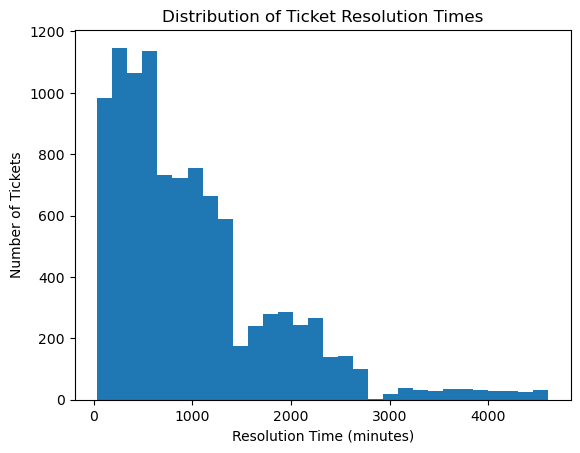

In [9]:
plt.hist(df["resolution_time_minutes"], bins=30)

plt.xlabel("Resolution Time (minutes)")
plt.ylabel("Number of Tickets")
plt.title("Distribution of Ticket Resolution Times")

plt.show()

The distribution is right-skewed. Most tickets are resolved within a lower time range, while a smaller number of tickets take much longer.

This explains why the average resolution time is higher than the median and why percentiles such as P90 are useful for describing slower tickets.

## Resolution Time by Priority

I compared resolution-time distributions across priority levels to see whether ticket urgency is associated with different resolution patterns.

C:\Users\Notebook\AppData\Local\Temp\ipykernel_25724\325586642.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


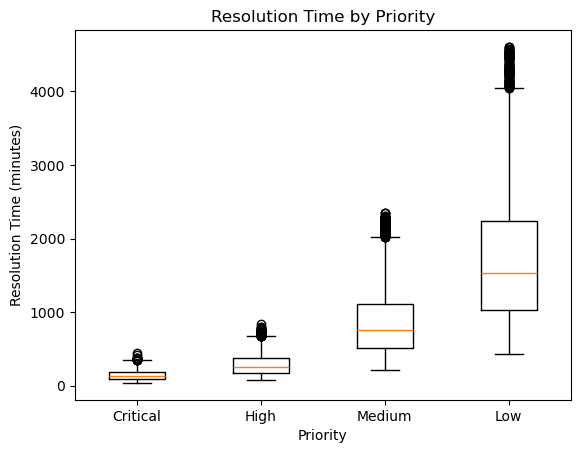

In [18]:
priority_order = ["Critical", "High", "Medium", "Low"]

resolution_by_priority = [
    df.loc[df["priority_name"] == priority, "resolution_time_minutes"]
    for priority in priority_order
]


plt.boxplot(
    resolution_by_priority, labels=priority_order
)

plt.xlabel("Priority")
plt.ylabel("Resolution Time (minutes)")
plt.title("Resolution Time by Priority")

plt.show()

Critical tickets have the lowest median resolution time, while lower-priority tickets generally take longer and show greater variability.

Potential high-end outliers are visible across all priority groups.

## Critical Ticket Reassignment Analysis

The SQL analysis showed that reassigned Critical tickets had a much higher response SLA breach rate than non-reassigned Critical tickets.

Because the reassigned group contains relatively few tickets, I used confidence intervals to quantify the uncertainty around the observed breach rates.

In [11]:
critical_df = df[df["priority_name"] == "Critical"].copy()

critical_df.shape


(599, 39)

### 95% Confidence Intervals

Because the reassigned Critical group is relatively small, I calculated 95% Wilson confidence intervals to show the uncertainty around the observed breach rates.

In [12]:
from statsmodels.stats.proportion import proportion_confint


reassigned = critical_df[critical_df["is_reassigned"] == True]

n = len(reassigned)

breaches = reassigned["response_sla_breached"].sum()


ci_low, ci_high = proportion_confint(
    count=breaches,
    nobs=n,
    alpha=0.05,
    method="wilson"
)

print(round(ci_low * 100, 2))
print(round(ci_high * 100, 2))


not_reassigned = critical_df[critical_df["is_reassigned"] == False]

n_not = len(not_reassigned)

breaches_not = not_reassigned["response_sla_breached"].sum()

ci_low_not, ci_high_not = proportion_confint(
    count=breaches_not,
    nobs=n_not,
    alpha=0.05,
    method="wilson"
)
print(round(ci_low_not * 100, 2))
print(round(ci_high_not * 100, 2))

71.22
92.25
29.77
37.61


### Two-Proportion Z-Test

The test evaluates whether the response SLA breach rates differ statistically between reassigned and non-reassigned Critical tickets.

H0: The breach rates are equal.

H1: The breach rates are different.

In [13]:
from statsmodels.stats.proportion import proportions_ztest

count = [
    reassigned["response_sla_breached"].sum(),
    not_reassigned["response_sla_breached"].sum()
]


nobs = [ len(reassigned),  len(not_reassigned)]


z_stat, p_value = proportions_ztest(count, nobs)

print("Z-statistic:", round(z_stat, 2))
print("P-value:", p_value)

Z-statistic: 6.78
P-value: 1.1797886425919524e-11


In [14]:
summary = (
    critical_df
    .groupby("is_reassigned")["response_sla_breached"]
    .agg(["count", "sum", "mean"])
)

summary.columns = ["n", "breaches", "breach_rate"]

summary["breach_rate"] = ( summary["breach_rate"] * 100).round(2)

summary.index = ["Not reassigned", "Reassigned"]

summary

,n,breaches,breach_rate
Not reassigned,554,186,33.57
Reassigned,45,38,84.44


In [17]:
summary["ci_low"] = [
    ci_low_not * 100,
    ci_low * 100
]

summary["ci_high"] = [
    ci_high_not * 100,
    ci_high * 100
]

summary[["ci_low", "ci_high"]] = (
    summary[["ci_low", "ci_high"]].round(2)
)


summary

,n,breaches,breach_rate,ci_low,ci_high
Not reassigned,554,186,33.57,29.77,37.61
Reassigned,45,38,84.44,71.22,92.25


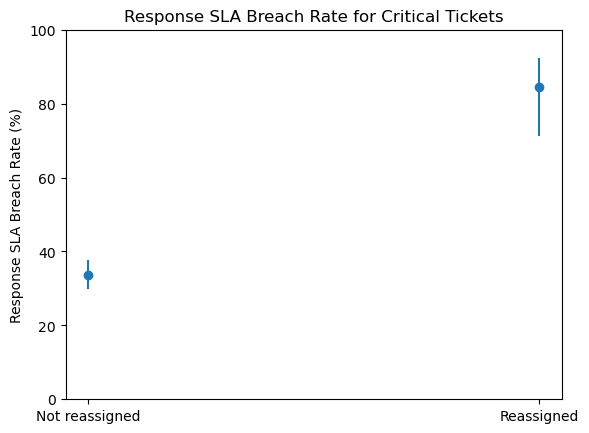

In [16]:
plt.vlines(
    x=summary.index,
    ymin=summary["ci_low"],
    ymax=summary["ci_high"]
)

plt.scatter(
    summary.index,
    summary["breach_rate"]
)

plt.ylabel("Response SLA Breach Rate (%)")
plt.title("Response SLA Breach Rate for Critical Tickets")
plt.ylim(0, 100)

plt.show()

The reassigned Critical group had a response SLA breach rate of 84.4%, compared with 33.6% for non-reassigned tickets.

The difference was statistically significant (p < 0.001). However, this result shows an association between reassignment and SLA breach and does not establish causation.